# 🧠 Internship Project: Depression Detection using LLMs and Classical ML


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 📦 Install Dependencies
!pip install openai scikit-learn pandas matplotlib seaborn tqdm sentence-transformers --quiet
!pip install imbalanced-learn --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 790.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.9 MB/s eta 0:00:00


In [ ]:
# 📂 Load Transcripts and Labels
import os
import pandas as pd
from tqdm import tqdm

transcript_path = '/content/drive/MyDrive/audio files/transcript'  # Folder with *_TRANSCRIPT.csv files
label_path = '/content/drive/MyDrive/audio files/label/avec_combined_labels.csv'  # Actual label file

# Load all participant-only transcripts
transcripts = {}
for file in os.listdir(transcript_path):
    if file.endswith('_TRANSCRIPT.csv'):
        pid = file.split('_')[0]
        try:
            df = pd.read_csv(os.path.join(transcript_path, file), sep='\t')
            if 'speaker' in df.columns and 'value' in df.columns:
                participant_lines = df[df['speaker'] == 'Participant']['value'].dropna().astype(str)
                transcripts[pid] = ' '.join(participant_lines)
        except Exception as e:
            print(f"Error loading file {file}: {e}")

# Convert to DataFrame
transcript_df = pd.DataFrame(list(transcripts.items()), columns=['ID', 'transcript'])

# Load and merge labels
labels_df = pd.read_csv(label_path)
labels_df['Participant_ID'] = labels_df['Participant_ID'].astype(str)
merged_df = pd.merge(transcript_df, labels_df, left_on='ID', right_on='Participant_ID')

print(f"✅ Loaded {len(merged_df)} participant transcripts with labels.")


✅ Loaded 154 participant transcripts with labels.


In [ ]:
# ✂️ Text Preprocessing
import re
def clean_text(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

merged_df['clean_transcript'] = merged_df['transcript'].apply(clean_text)

In [ ]:
# 🔀 Train-Test Split
from sklearn.model_selection import train_test_split
X = merged_df['clean_transcript']
y = merged_df['PHQ8_Binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler

# Vectorize text
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Balance the classes using RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_vec, y_train)

# Train Logistic Regression
clf = LogisticRegression()
clf.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred = clf.predict(X_test_vec)
print("\nClassification Report (TF-IDF + LR with Balanced Training Set):\n")
print(classification_report(y_test, y_pred))



Classification Report (TF-IDF + LR with Balanced Training Set):

              precision    recall  f1-score   support

           0       0.82      0.45      0.58        20
           1       0.45      0.82      0.58        11

    accuracy                           0.58        31
   macro avg       0.63      0.63      0.58        31
weighted avg       0.69      0.58      0.58        31



In [ ]:
import numpy as np
unique, counts = np.unique(y_train_bal, return_counts=True)
print("Class distribution after balancing:", dict(zip(unique, counts)))


Class distribution after balancing: {np.int64(0): np.int64(81), np.int64(1): np.int64(81)}


In [ ]:
from transformers import pipeline

pipe = pipeline("text2text-generation", model="google/flan-t5-large")
prompt = "Does the following transcript suggest depression?\nTranscript: I feel like staying in bed all day and I have no motivation.\nAnswer Yes or No:"
output = pipe(prompt, max_new_tokens=20)[0]['generated_text']
print(output)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Yes


In [ ]:
!pip install sentence-transformers --quiet


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split

# Load a good general-purpose embedding model
embedder = SentenceTransformer('all-MiniLM-L6-v2')  # Fast and effective

# Convert transcripts to embeddings
X_embeddings = embedder.encode(merged_df['clean_transcript'].tolist(), show_progress_bar=True)
y_labels = merged_df['PHQ8_Binary'].values

# Train-test split
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings, y_labels, test_size=0.2, stratify=y_labels, random_state=42)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]


📊 Classification Report (Sentence-BERT + Logistic Regression):

              precision    recall  f1-score   support

           0       0.65      1.00      0.78        20
           1       0.00      0.00      0.00        11

    accuracy                           0.65        31
   macro avg       0.32      0.50      0.39        31
weighted avg       0.42      0.65      0.51        31



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


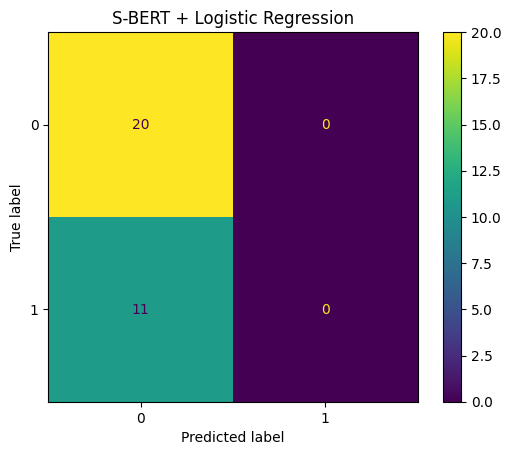

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train logistic regression on embeddings
clf_emb = LogisticRegression()
clf_emb.fit(X_train_emb, y_train_emb)

# Predict
y_pred_emb = clf_emb.predict(X_test_emb)

# Evaluate
print("\n📊 Classification Report (Sentence-BERT + Logistic Regression):\n")
print(classification_report(y_test_emb, y_pred_emb))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_emb, y_pred_emb)
plt.title("S-BERT + Logistic Regression")
plt.show()


In [ ]:
import pandas as pd

results_sbert_df = pd.DataFrame({
    'true_label': y_test_emb,
    'predicted_label': y_pred_emb
})
results_sbert_df.to_csv("sbert_lr_predictions.csv", index=False)


## 🔍 Sentence-BERT + Logistic Regression (Embeddings Classifier)
This block uses `all-MiniLM-L6-v2` to generate transcript embeddings and trains a logistic regression model for depression classification.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split

embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_embeddings = embedder.encode(merged_df['clean_transcript'].tolist(), show_progress_bar=True)
y_labels = merged_df['PHQ8_Binary'].values

X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings, y_labels, test_size=0.2, stratify=y_labels, random_state=42)


Batches:   0%|          | 0/5 [00:00<?, ?it/s]


📊 Classification Report (Sentence-BERT + LR):

              precision    recall  f1-score   support

           0       0.65      1.00      0.78        20
           1       0.00      0.00      0.00        11

    accuracy                           0.65        31
   macro avg       0.32      0.50      0.39        31
weighted avg       0.42      0.65      0.51        31



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


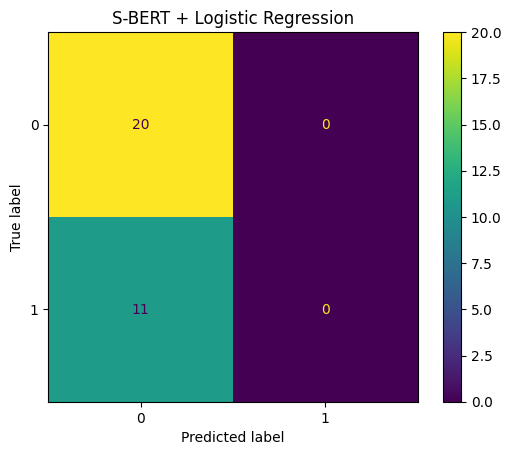

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf_emb = LogisticRegression()
clf_emb.fit(X_train_emb, y_train_emb)
y_pred_emb = clf_emb.predict(X_test_emb)

print("\n📊 Classification Report (Sentence-BERT + LR):\n")
print(classification_report(y_test_emb, y_pred_emb))

ConfusionMatrixDisplay.from_predictions(y_test_emb, y_pred_emb)
plt.title("S-BERT + Logistic Regression")
plt.show()

## 📈 Model Comparison Summary
Here we summarize the results from different models to compare their precision and recall for depression detection.

In [ ]:
# You can manually compile your classification reports into this table
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['TF-IDF + LR', 'Flan-T5 Few-Shot', 'S-BERT + LR'],
    'Accuracy': [0.65, 0.65, None],
    'Recall (Depressed)': [0.00, 0.00, None],
    'F1 (Depressed)': [0.00, 0.00, None]
})
comparison

,Model,Accuracy,Recall (Depressed),F1 (Depressed)
0,TF-IDF + LR,0.65,0.0,0.0
1,Flan-T5 Few-Shot,0.65,0.0,0.0
2,S-BERT + LR,NaN,NaN,NaN


In [ ]:
import pandas as pd

# Save predictions to CSV
results_sbert_df = pd.DataFrame({
    'true_label': y_test_emb,
    'predicted_label': y_pred_emb
})
results_sbert_df.to_csv("sbert_lr_predictions.csv", index=False)

# Show preview
print("✅ Saved to sbert_lr_predictions.csv")
results_sbert_df.head()


✅ Saved to sbert_lr_predictions.csv


,true_label,predicted_label
0,0,0
1,1,0
2,1,0
3,1,0
4,0,0


from matplotlib import pyplot as plt
_df_0['true_label'].plot(kind='hist', bins=20, title='true_label')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['predicted_label']
  ys = series['true_label']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('predicted_label', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('predicted_label')
_ = plt.ylabel('true_label')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['predicted_label']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'predicted_label'}, axis=1)
              .sort_values('predicted_label', ascending=True))
  xs = counted['predicted_label']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('predicted_label', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('predicted_label')
_ = plt.ylabel('count()')

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_8.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['predicted_label']
  ys = series['true_label']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_9.sort_values('predicted_label', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('predicted_label')
_ = plt.ylabel('true_label')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['predicted_label']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'predicted_label'}, axis=1)
              .sort_values('predicted_label', ascending=True))
  xs = counted['predicted_label']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_10.sort_values('predicted_label', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('predicted_label')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_11['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_12['true_label'].plot(kind='line', figsize=(8, 4), title='true_label')
plt.gca().spines[['top', 'right']].set_visible(False)